# Phase 2: Data Summarization and Preprocessing

## 1. Data Analysis
In this section, we apply different summarization and visualization techniques to better understand our dataset.

### 1.1 Missing Values and Statistical Summaries

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset
df = pd.read_excel('Raw_dataset.xlsx')

In [ ]:
# count missing values in each column
print(df.isna().sum())

Age               0
Sex               0
ChestPainType     0
RestingBP         0
Cholesterol       0
FastingBS         0
RestingECG        0
MaxHR             0
ExerciseAngina    0
Oldpeak           0
ST_Slope          0
HeartDisease      0
dtype: int64


**1. Finding missing values**

It shows that the dataset contains no missing values(null) across all attributes but further inspection shows that there are implicit missing values such as zero values in Cholesterol.







In [ ]:
# Exclude binary variables since they are nominal attributes
df.drop(columns=['HeartDisease','FastingBS']).describe()

,Age,RestingBP,Cholesterol,MaxHR,Oldpeak
count,918.000000,918.000000,918.000000,918.000000,918.000000
mean,53.510893,132.396514,198.799564,136.809368,0.887364
std,9.432617,18.514154,109.384145,25.460334,1.066570
min,28.000000,0.000000,0.000000,60.000000,-2.600000
25%,47.000000,120.000000,173.250000,120.000000,0.000000
50%,54.000000,130.000000,223.000000,138.000000,0.600000
75%,60.000000,140.000000,267.000000,156.000000,1.500000
max,77.000000,200.000000,603.000000,202.000000,6.200000


**2. Five number summary for numeric attributes**

- **Cholesterol & RestingBP**: Show biologically invalid minimums of 0 (implicit missing values/errors) alongside extreme upper maximums (603 & 200).
- **Age**: Ranges normally between 28 and 77 years (Median: 54).
- **MaxHR**: Spans from 60 to 202 bpm (Median: 138).
- **Oldpeak**: Ranges from -2.6 to 6.2 with potential outliers beyond the whiskers.


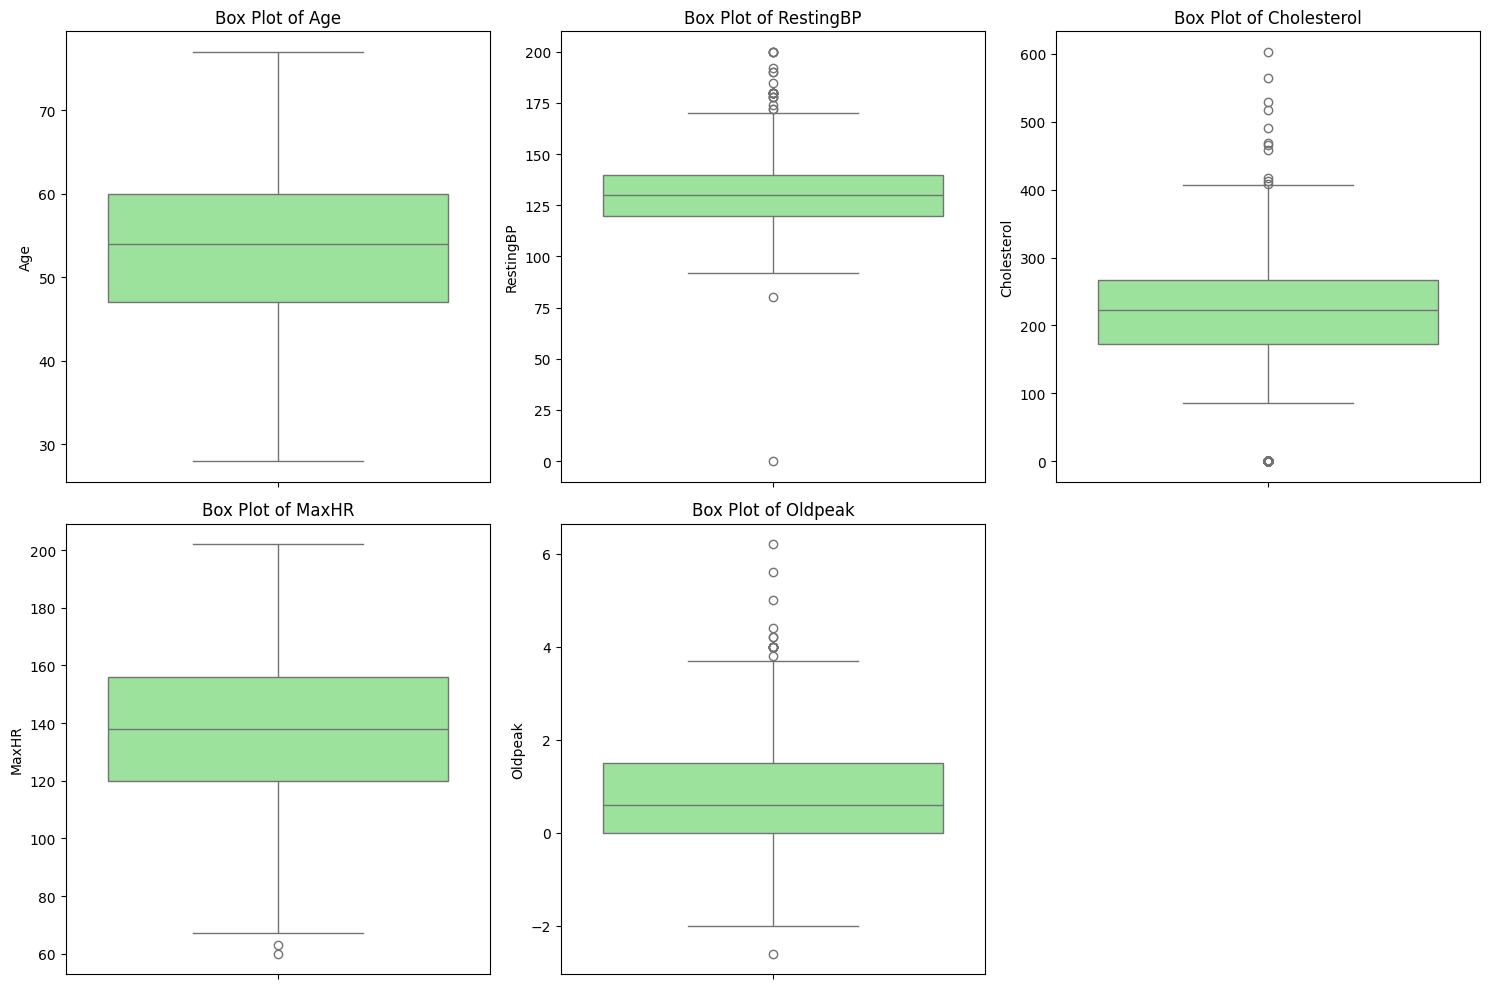

In [ ]:
numeric_cols = ['Age', 'RestingBP', 'Cholesterol', 'MaxHR', 'Oldpeak']

# Set figure size for a 2x3 grid
plt.figure(figsize=(15, 10))

# Loop through each numeric column to create a box plot
for i, col in enumerate(numeric_cols, 1):
    plt.subplot(2, 3, i)
    sns.boxplot(y=df[col], color='lightgreen')
    plt.title(f'Box Plot of {col}')
    plt.ylabel(col)

# Adjust layout to prevent overlapping
plt.tight_layout()
plt.show()



**3. Outlier Analysis & Data Distribution**



The boxplots show the spread, median, and outliers of each numeric attribute. Outliers are the points outside the whiskers (1.5 × IQR from Q1 and Q3).



- **Cholesterol**: Has the largest number of outliers. Many points lie at exactly 0, below the lower whisker, along with several extreme values above roughly 400 mg/dL (up to 603). A cholesterol level of 0 is biologically impossible, so these zeros are implicit missing values rather than real measurements.

- **RestingBP**: The box is narrow (120–140), but there are upper outliers above 170 mmHg (up to 200) and a single impossible value at 0.

- **Oldpeak**: Most values are concentrated between 0 and 1.5, with several upper outliers above 3.75 (up to 6.2) and a few negative values below the lower whisker.

- **MaxHR**: Fairly symmetric, with only a few low outliers around 60 bpm.

- **Age**: Symmetric with no outliers, since all values (28–77) lie within the whiskers.



**Why Preprocessing is needed:** The boxplots confirm that Cholesterol and RestingBP contain invalid zero values that must be replaced, and that RestingBP, Cholesterol, Oldpeak, and MaxHR contain extreme outliers that could distort the analysis. This justifies applying **Noise Removal** (replacing the zeros with the median and capping outliers at the IQR limits).

### 1.2 Data Visualization & Descriptions

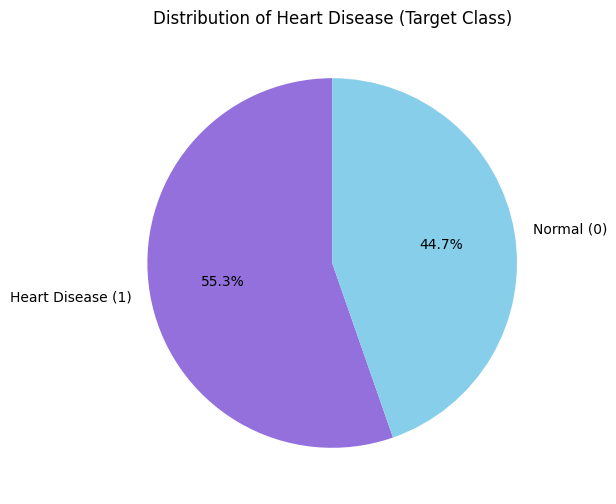

In [ ]:
plt.figure(figsize=(6, 6))
heart_disease_freq = df['HeartDisease'].value_counts(normalize=True) * 100
heart_disease_freq.plot.pie(autopct='%1.1f%%', startangle=90, labels=['Heart Disease (1)', 'Normal (0)'], colors=['mediumpurple', 'skyblue'])
plt.title('Distribution of Heart Disease (Target Class)')
plt.ylabel('')
plt.show()

**1. Class Label Distribution (Pie Chart)**
* **Description:** This pie chart illustrates the distribution of the target variable `HeartDisease`. It shows that 55.3% of the patients have heart disease (class 1), while 44.7% are normal (class 0).
* **Why Preprocessing is needed:** The chart shows that our target class is well-balanced (55.3% vs 44.7%), suggesting that class-balancing techniques may not be necessary. Therefore, our preprocessing must focus on cleaning and preparing the input features to help the model accurately predict these two classes.

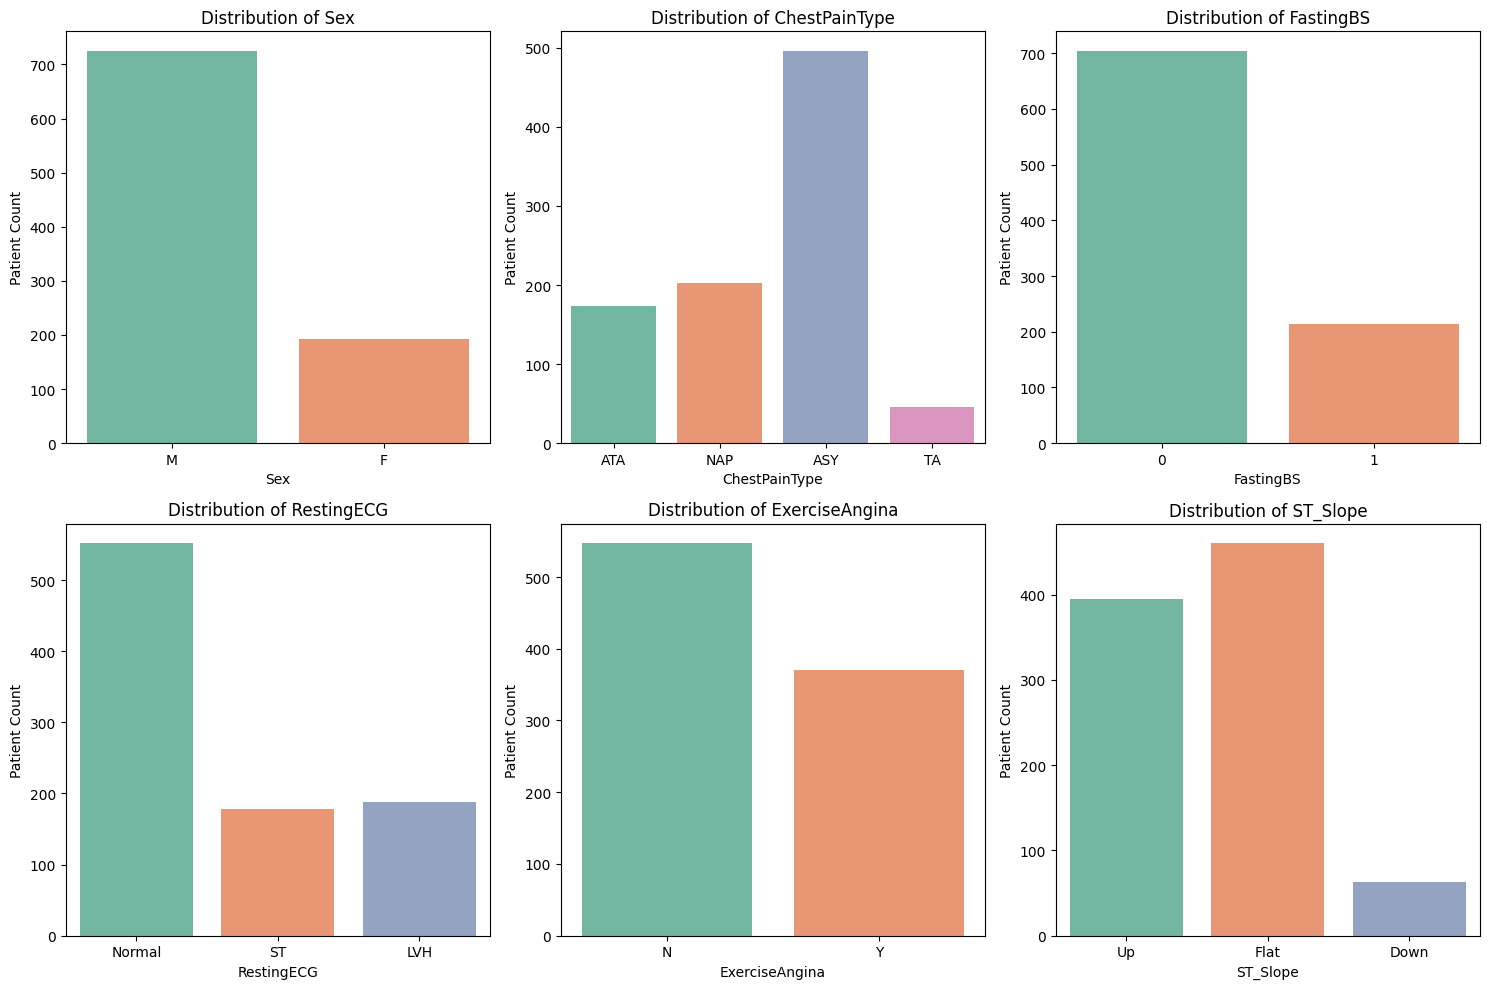

In [ ]:
nominal_cols = ['Sex', 'ChestPainType', 'FastingBS', 'RestingECG',
                'ExerciseAngina', 'ST_Slope']

# Set figure size for a 2x3 grid (since we have exactly 6 columns)
plt.figure(figsize=(15, 10))

# Loop through each nominal column to create a bar plot
for i, col in enumerate(nominal_cols, 1):
    plt.subplot(2, 3, i)
    # The fix: added hue=df[col] and legend=False to comply with the new Seaborn update
    sns.countplot(x=df[col], hue=df[col], palette='Set2', legend=False)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Patient Count')

# Adjust layout to prevent overlapping
plt.tight_layout()
plt.show()

**2. Nominal Attributes Distribution (Bar Plot)**
* **Description:** The bar plots visualize the frequency of six categorical attributes: Sex, ChestPainType, FastingBS, RestingECG, ExerciseAngina, and ST_Slope. For ChestPainType, ‘ASY’ (Asymptomatic) is clearly the most common type.
* **Why Preprocessing is needed:** The x-axis shows distinct categorical groups (e.g., ‘ASY’, ‘NAP’, ‘ATA’). These plots help us understand the distribution of categorical attributes and highlight the need for categorical encoding when using machine learning algorithms that require numerical inputs.

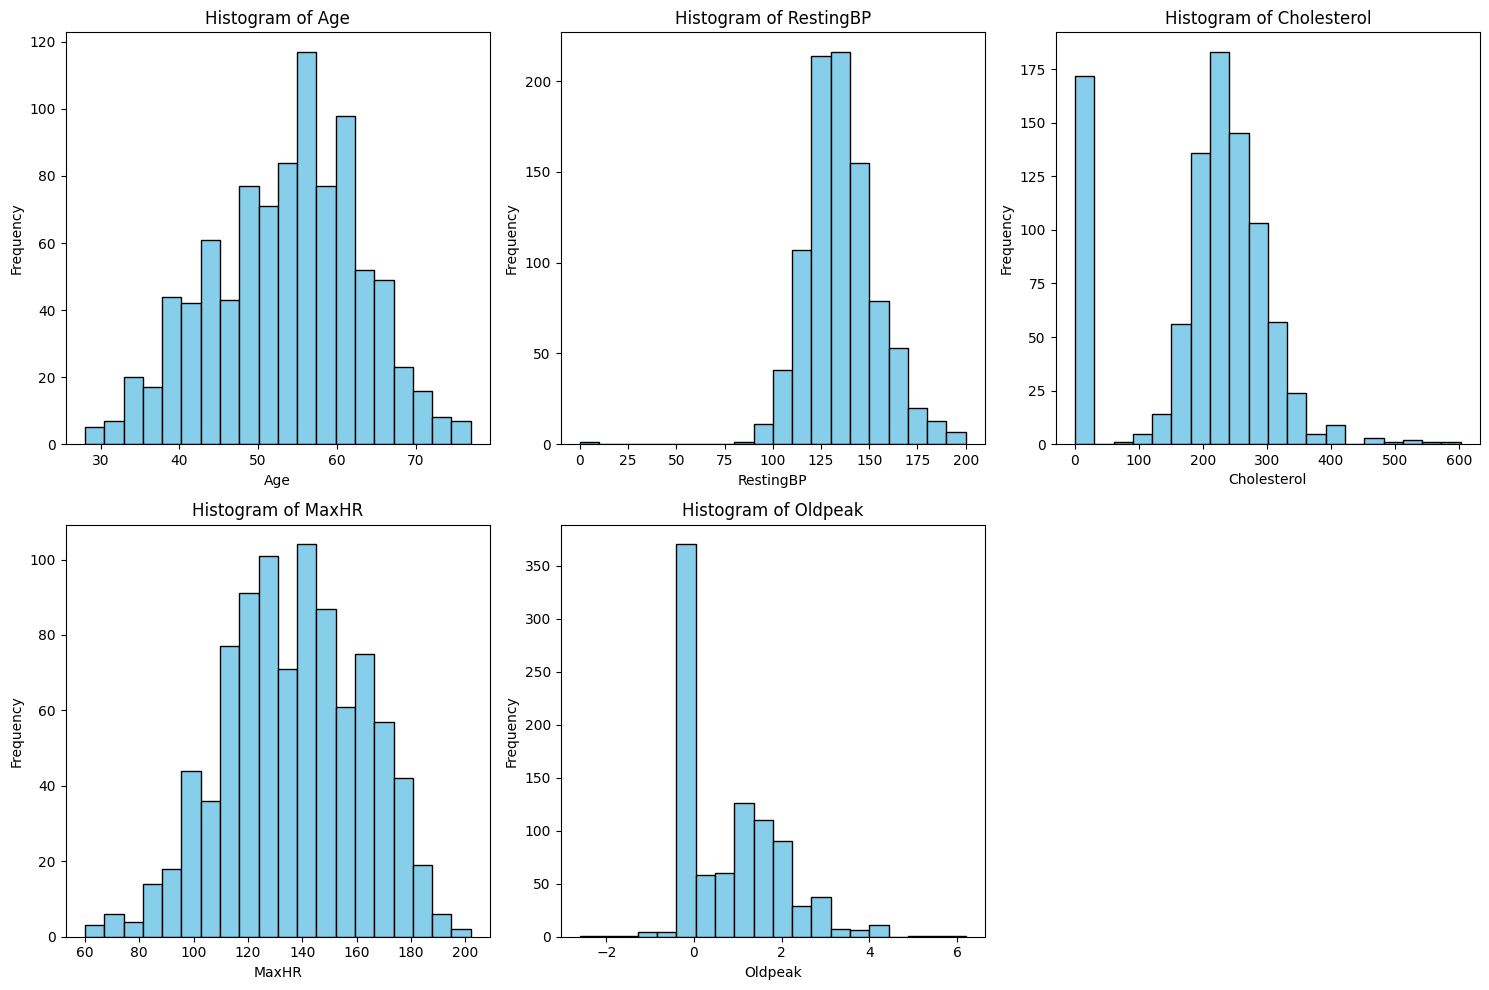

In [ ]:
numeric_cols = ['Age', 'RestingBP', 'Cholesterol', 'MaxHR', 'Oldpeak']

# Set figure size for a 2x3 grid
plt.figure(figsize=(15, 10))

# Loop through each numeric column to create a histogram
for i, col in enumerate(numeric_cols, 1):
    plt.subplot(2, 3, i)
    df[col].plot.hist(bins=20, color='skyblue', edgecolor='black')
    plt.title(f'Histogram of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')

# Adjust layout to prevent overlapping
plt.tight_layout()
plt.show()

**3. Numeric Attributes Distribution (Histogram)**
* **Description:**  These histograms display the distributions of five numerical attributes: Age, RestingBP, Cholesterol, MaxHR, and Oldpeak. Age is mostly concentrated between 40 and 65, RestingBP around 120–150, and MaxHR around 100–170. Oldpeak has a right-skewed distribution, while Cholesterol shows a noticeable spike at zero.
* **Why Preprocessing is needed:** A significant anomaly is visible: there is a massive spike exactly at the value `0` (172 instances). Biologically, a cholesterol level of zero is impossible, which indicates missing data or input noise. This proves a strong need for **Data Cleaning and Noise Removal** (e.g., replacing these zeros with the median cholesterol value) before feeding it to a model.


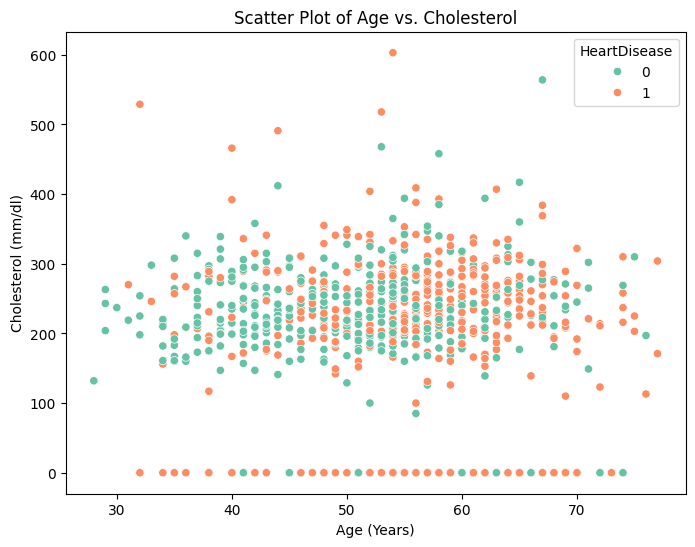

In [ ]:
plt.figure(figsize=(8, 6))
sns.scatterplot(x='Age', y='Cholesterol', data=df, hue='HeartDisease', palette='Set2')
plt.title('Scatter Plot of Age vs. Cholesterol')
plt.xlabel('Age (Years)')
plt.ylabel('Cholesterol (mm/dl)')
plt.show()

**4. Exploring Multiple Variables (Scatter Plot)**
* **Description:** The scatter plot explores the relationship between `Age` and `Cholesterol`, colored by the presence of heart disease.
* **Why Preprocessing is needed:** Looking at the axes, `Age` ranges roughly from 28 to 77, whereas `Cholesterol` jumps from 0 to over 600. This massive difference in numerical scales (tens vs. hundreds) can negatively impact distance-based algorithms like K-Means clustering. This clearly justifies the need for **Data Normalization (Scaling)** to bring all numeric features to a standard scale.

## 2. Data Preprocessing
Based on the insights gained from the Data Analysis section, we applied three different preprocessing techniques.

### 2.1 Technique 1: Noise Removal

*   **Justification and Results:**
Cholesterol (172 records) and RestingBP (1 record) had values of 0, which are biologically impossible, so they were replaced with the median of each attribute. Extreme outliers in Age, RestingBP, Cholesterol, MaxHR, and Oldpeak were filtered out using the Z-score method (with a threshold of 3 standard deviations) to ensure data quality. After cleaning and removing extreme outliers, the dataset size was adjusted from 918 to 890 records, leaving a clean and reliable dataset.

In [ ]:
import numpy as np
from scipy.stats import zscore

# Work on a copy so the raw dataset (df) stays unchanged
df_preprocessed = df.copy()

# Step 1: Replace impossible zero values with NaN, then impute with the median
for col in ['RestingBP', 'Cholesterol']:
    df_preprocessed[col] = df_preprocessed[col].replace(0, np.nan)

print("Impossible zero values found:")
print(df_preprocessed[['RestingBP', 'Cholesterol']].isna().sum())

medians = df_preprocessed[['RestingBP', 'Cholesterol']].median()
df_preprocessed[['RestingBP', 'Cholesterol']] = df_preprocessed[['RestingBP', 'Cholesterol']].fillna(medians)

print("\nMedians used for imputation:")
print(medians)

# Step 2: Apply Z-Score on numerical columns to remove extreme outliers
numeric_cols = ['Age', 'RestingBP', 'Cholesterol', 'MaxHR', 'Oldpeak']

# Calculate the z-score for all numerical columns
z_scores = np.abs(zscore(df_preprocessed[numeric_cols]))

# Keep only the rows that fall within the normal range (less than 3 standard deviations)
df_preprocessed = df_preprocessed[(z_scores < 3).all(axis=1)]

print("\nNew shape after Z-score outlier removal:", df_preprocessed.shape)

# Correlation check
print("\nCorrelation of Cholesterol with HeartDisease:")
print("before: ", df['Cholesterol'].corr(df['HeartDisease']))
print("after : ", df_preprocessed['Cholesterol'].corr(df_preprocessed['HeartDisease']))


Impossible zero values found:
RestingBP        1
Cholesterol    172
dtype: int64

Medians used for imputation:
RestingBP      130.0
Cholesterol    237.0
dtype: float64

New shape after Z-score outlier removal: (890, 12)

Correlation of Cholesterol with HeartDisease:
before:  -0.23274063892701105
after :  0.0787086241969746


### 2.2 Technique 2: Discretization
* **Justification and Results:** Age is a continuous numerical attribute. Discretization was applied to divide Age into meaningful age groups: ≤30, 31–40, 41–50, 51–60, 61–70, and >70. This makes the data easier to interpret and allows patterns across different age ranges to be analyzed more clearly. A new categorical attribute, Age_Group, was created while preserving the original Age attribute.

In [ ]:
# Discretization of Age

# Define age intervals
bins = [0, 30, 40, 50, 60, 70, 100]
labels = ['≤30', '31-40', '41-50', '51-60', '61-70', '>70']

# Apply discretization to Age and save it in a NEW column (Age_Group)
df_preprocessed['Age_Group'] = pd.cut(
    df_preprocessed['Age'],
    bins=bins,
    labels=labels,
    include_lowest=True
)

# Show the result before and after discretization
print("Age before discretization (Original):")
print(df['Age'].head(10))

print("\nAge after discretization (New Column):")
print(df_preprocessed['Age_Group'].head(10))

# Show the number of patients in each age group
print("\nNumber of patients in each age group:")
print(df_preprocessed['Age_Group'].value_counts().sort_index())


Age before discretization (Original):
0    40
1    49
2    37
3    48
4    54
5    39
6    45
7    54
8    37
9    48
Name: Age, dtype: int64

Age after discretization (New Column):
0    31-40
1    41-50
2    31-40
3    41-50
4    51-60
5    31-40
6    41-50
7    51-60
8    31-40
9    41-50
Name: Age_Group, dtype: category
Categories (6, object): ['≤30' < '31-40' < '41-50' < '51-60' < '61-70' < '>70']

Number of patients in each age group:
Age_Group
≤30        5
31-40     85
41-50    219
51-60    367
61-70    190
>70       24
Name: count, dtype: int64


### 2.3 Technique 3: Data Normalization (Scaling)

*  **Justification and Results:**
Min-Max Normalization was applied to all numeric attributes (Age, RestingBP, Cholesterol, MaxHR, and Oldpeak) using MinMaxScaler. These attributes have different numerical ranges, so scaling them to [0, 1] makes them comparable and reduces the influence of their original scales. The before-and-after results show that all these attributes were successfully normalized.

In [ ]:
from sklearn.preprocessing import MinMaxScaler

# Select numerical columns for normalization
columns_to_scale = ['Age', 'RestingBP', 'Cholesterol', 'MaxHR', 'Oldpeak']

# Save original values before normalization
before_scaling = df_preprocessed[columns_to_scale].copy()

# Apply Min-Max Normalization
scaler = MinMaxScaler()

df_preprocessed[columns_to_scale] = scaler.fit_transform(
df_preprocessed[columns_to_scale]
)

# Display values before and after normalization
print("Before Normalization:")
print(before_scaling.head(10))

print("\nAfter Normalization:")
print(df_preprocessed[columns_to_scale].head(10))


Before Normalization:
   Age  RestingBP  Cholesterol  MaxHR  Oldpeak
0   40      140.0        289.0    172      0.0
1   49      160.0        180.0    156      1.0
2   37      130.0        283.0     98      0.0
3   48      138.0        214.0    108      1.5
4   54      150.0        195.0    122      0.0
5   39      120.0        339.0    170      0.0
6   45      130.0        237.0    170      0.0
7   54      110.0        208.0    142      0.0
8   37      140.0        207.0    130      1.5
9   48      120.0        284.0    120      0.0

After Normalization:
        Age  RestingBP  Cholesterol     MaxHR   Oldpeak
0  0.244898   0.571429     0.660194  0.784173  0.333333
1  0.428571   0.761905     0.307443  0.669065  0.500000
2  0.183673   0.476190     0.640777  0.251799  0.333333
3  0.408163   0.552381     0.417476  0.323741  0.583333
4  0.530612   0.666667     0.355987  0.424460  0.333333
5  0.224490   0.380952     0.822006  0.769784  0.333333
6  0.346939   0.476190     0.491909  0.769784  

### 2.4 Final SnapShot

In [ ]:
print("Snapshot of the RAW dataset:")
display(df.head(10))

print("Snapshot of the PREPROCESSED dataset:")
display(df_preprocessed.head(10))

print("Raw shape:", df.shape, "| Preprocessed shape:", df_preprocessed.shape)

df_preprocessed.to_excel('Preprocessed_dataset.xlsx', index=False)
print("Saved as Preprocessed_dataset.xlsx")

Snapshot of the RAW dataset:


,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0
5,39,M,NAP,120,339,0,Normal,170,N,0.0,Up,0
6,45,F,ATA,130,237,0,Normal,170,N,0.0,Up,0
7,54,M,ATA,110,208,0,Normal,142,N,0.0,Up,0
8,37,M,ASY,140,207,0,Normal,130,Y,1.5,Flat,1
9,48,F,ATA,120,284,0,Normal,120,N,0.0,Up,0


Snapshot of the PREPROCESSED dataset:


,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease,Age_Group
0,0.244898,M,ATA,0.571429,0.660194,0,Normal,0.784173,N,0.333333,Up,0,31-40
1,0.428571,F,NAP,0.761905,0.307443,0,Normal,0.669065,N,0.500000,Flat,1,41-50
2,0.183673,M,ATA,0.476190,0.640777,0,ST,0.251799,N,0.333333,Up,0,31-40
3,0.408163,F,ASY,0.552381,0.417476,0,Normal,0.323741,Y,0.583333,Flat,1,41-50
4,0.530612,M,NAP,0.666667,0.355987,0,Normal,0.424460,N,0.333333,Up,0,51-60
5,0.224490,M,NAP,0.380952,0.822006,0,Normal,0.769784,N,0.333333,Up,0,31-40
6,0.346939,F,ATA,0.476190,0.491909,0,Normal,0.769784,N,0.333333,Up,0,41-50
7,0.530612,M,ATA,0.285714,0.398058,0,Normal,0.568345,N,0.333333,Up,0,51-60
8,0.183673,M,ASY,0.571429,0.394822,0,Normal,0.482014,Y,0.583333,Flat,1,31-40
9,0.408163,F,ATA,0.380952,0.644013,0,Normal,0.410072,N,0.333333,Up,0,41-50


Raw shape: (918, 12) | Preprocessed shape: (890, 13)
Saved as Preprocessed_dataset.xlsx
